# Comparison of CenterPoint and BEVFusion on nuScenes 20% and 40% subsets

This notebook compares CenterPoint and BEVFusion trained on reduced nuScenes training subsets.

The goal is to compare:
- training loss behavior
- final NDS and mAP
- global nuScenes error metrics
- per-class detection performance

# Import

In [2]:
import pandas as pd

from pathlib import Path
from typing import Dict, Final, List
from pprint import pprint


# Config

In [7]:
# Root project directory
PROJECT_ROOT: Final[Path] = (
    Path.cwd().resolve().parent
)

print("Project root:")
print(PROJECT_ROOT)

CONFIG: Dict[str, object] = {

    # Results directory
    "metrics_dir":
        PROJECT_ROOT / "results" / "final_metrics",

    # Experiment metric files
    "metrics_files": [

        "centerpoint_nuscenes_20pct_10ep_run1_metrics.csv",

        "centerpoint_nuscenes_40pct_10ep_run1_metrics.csv",

        "bevfusion_nuscenes_20pct_10ep_run1_metrics.csv",

        "bevfusion_nuscenes_40pct_10ep_run1_metrics.csv",
    ],
}

pprint(CONFIG)

Project root:
/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning
{'metrics_dir': PosixPath('/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/results/final_metrics'),
 'metrics_files': ['centerpoint_nuscenes_20pct_10ep_run1_metrics.csv',
                   'centerpoint_nuscenes_40pct_10ep_run1_metrics.csv',
                   'bevfusion_nuscenes_20pct_10ep_run1_metrics.csv',
                   'bevfusion_nuscenes_40pct_10ep_run1_metrics.csv']}


# Load experiment metrics

This section loads the cleaned metrics exported from each experiment notebook and combines them into a single dataframe for comparison.

In [8]:
METRICS_DIR: Final[Path] = CONFIG["metrics_dir"]
metrics_files: Final[List[str]] = CONFIG["metrics_files"]

dfs: List[pd.DataFrame] = []

for file_name in metrics_files:

    file_path: Path = METRICS_DIR / file_name

    df: pd.DataFrame = pd.read_csv(file_path)

    dfs.append(df)

metrics_df: pd.DataFrame = pd.concat(dfs, ignore_index=True)

print(metrics_df.shape)

metrics_df.head()

(27, 105)


,run,epoch,step,car_AP_0.5,car_AP_1.0,car_AP_2.0,car_AP_4.0,car_ATE,car_ASE,car_AOE,...,traffic_cone_AOE,traffic_cone_AVE,traffic_cone_AAE,NDS,mAP,model,subset,experiment_name,gpu_type,max_epochs
0,20260511_181619,NaN,1,0.3929,0.5434,0.6480,0.7065,0.3293,0.1811,0.7177,...,NaN,NaN,NaN,0.278986,0.198266,centerpoint,20pct,centerpoint_nuscenes_20pct_10ep_run1,rtx4090,10
1,20260511_181619,NaN,2,0.4920,0.6376,0.7106,0.7526,0.2709,0.1770,0.5138,...,NaN,NaN,NaN,0.337484,0.263817,centerpoint,20pct,centerpoint_nuscenes_20pct_10ep_run1,rtx4090,10
2,20260511_181619,NaN,3,0.5181,0.6636,0.7349,0.7708,0.2696,0.1727,0.4092,...,NaN,NaN,NaN,0.386113,0.304838,centerpoint,20pct,centerpoint_nuscenes_20pct_10ep_run1,rtx4090,10
3,20260511_181619,NaN,4,0.5526,0.6964,0.7639,0.7939,0.2520,0.1692,0.3812,...,NaN,NaN,NaN,0.414214,0.340238,centerpoint,20pct,centerpoint_nuscenes_20pct_10ep_run1,rtx4090,10
4,20260512_001903,NaN,5,0.5749,0.7132,0.7761,0.8062,0.2405,0.1695,0.3280,...,NaN,NaN,NaN,0.434577,0.351107,centerpoint,20pct,centerpoint_nuscenes_20pct_10ep_run1,rtx4090,10


# Inspect loaded experiments

This section verifies that all experiments were loaded correctly and checks the available metadata and evaluation metrics.

In [9]:
print("Experiments:")
print(metrics_df["experiment_name"].unique())

print("\nModels:")
print(metrics_df["model"].unique())

print("\nSubsets:")
print(metrics_df["subset"].unique())

print("\nDataframe shape:")
print(metrics_df.shape)

Experiments:
['centerpoint_nuscenes_20pct_10ep_run1'
 'centerpoint_nuscenes_40pct_10ep_run1'
 'bevfusion_nuscenes_20pct_10ep_run1' 'bevfusion_nuscenes_40pct_10ep_run1']

Models:
['centerpoint' 'bevfusion']

Subsets:
['20pct' '40pct']

Dataframe shape:
(27, 105)


In [10]:
metrics_df[
    [
        "experiment_name",
        "epoch",
        "step",
        "NDS",
        "mAP",
    ]
].head(20)

,experiment_name,epoch,step,NDS,mAP
0,centerpoint_nuscenes_20pct_10ep_run1,NaN,1,0.278986,0.198266
1,centerpoint_nuscenes_20pct_10ep_run1,NaN,2,0.337484,0.263817
2,centerpoint_nuscenes_20pct_10ep_run1,NaN,3,0.386113,0.304838
3,centerpoint_nuscenes_20pct_10ep_run1,NaN,4,0.414214,0.340238
4,centerpoint_nuscenes_20pct_10ep_run1,NaN,5,0.434577,0.351107
5,centerpoint_nuscenes_20pct_10ep_run1,NaN,6,0.450570,0.358013
6,centerpoint_nuscenes_20pct_10ep_run1,NaN,7,0.473044,0.388224
7,centerpoint_nuscenes_20pct_10ep_run1,NaN,8,0.479367,0.393272
8,centerpoint_nuscenes_20pct_10ep_run1,NaN,9,0.486864,0.398193
9,centerpoint_nuscenes_40pct_10ep_run1,NaN,1,0.372520,0.296781


# Create experiment labels

This section creates simplified experiment labels used in plots and comparison tables.

In [11]:
# Create readable experiment labels
metrics_df["experiment_label"] = (
    metrics_df["model"].str.title()
    + " "
    + metrics_df["subset"].str.replace("pct", "%", regex=False)
)

metrics_df[
    [
        "experiment_name",
        "experiment_label",
        "step",
        "NDS",
        "mAP",
    ]
].head(20)

,experiment_name,experiment_label,step,NDS,mAP
0,centerpoint_nuscenes_20pct_10ep_run1,Centerpoint 20%,1,0.278986,0.198266
1,centerpoint_nuscenes_20pct_10ep_run1,Centerpoint 20%,2,0.337484,0.263817
2,centerpoint_nuscenes_20pct_10ep_run1,Centerpoint 20%,3,0.386113,0.304838
3,centerpoint_nuscenes_20pct_10ep_run1,Centerpoint 20%,4,0.414214,0.340238
4,centerpoint_nuscenes_20pct_10ep_run1,Centerpoint 20%,5,0.434577,0.351107
5,centerpoint_nuscenes_20pct_10ep_run1,Centerpoint 20%,6,0.450570,0.358013
6,centerpoint_nuscenes_20pct_10ep_run1,Centerpoint 20%,7,0.473044,0.388224
7,centerpoint_nuscenes_20pct_10ep_run1,Centerpoint 20%,8,0.479367,0.393272
8,centerpoint_nuscenes_20pct_10ep_run1,Centerpoint 20%,9,0.486864,0.398193
9,centerpoint_nuscenes_40pct_10ep_run1,Centerpoint 40%,1,0.372520,0.296781


# Final experiment metrics

This section extracts the final evaluation metrics from each experiment for direct comparison.


In [14]:
# Keep only the final evaluation step of each experiment
final_metrics_df = (
    metrics_df
    .sort_values("step")
    .groupby("experiment_label")
    .tail(1)
)

# Select key metrics
summary_df = final_metrics_df[
    [
        "experiment_label",
        "NDS",
        "mAP",
        "mATE",
        "mASE",
        "mAOE",
        "mAVE",
        "mAAE",
    ]
].copy()

# Round values for display
summary_df = summary_df.round(4)

# Sort experiments
summary_df = summary_df.sort_values("NDS", ascending=False)

summary_df

,experiment_label,NDS,mAP,mATE,mASE,mAOE,mAVE,mAAE
26,Bevfusion 40%,0.5754,0.5412,0.3359,0.2975,0.5839,0.5323,0.2021
16,Centerpoint 40%,0.5688,0.4783,0.3463,0.2706,0.4536,0.4217,0.2111
8,Centerpoint 20%,0.4869,0.3982,0.3740,0.2809,0.6220,0.6167,0.2288
22,Bevfusion 20%,0.4686,0.4489,0.3700,0.3014,0.6561,0.9719,0.2590


# NDS comparison

This section compares the NuScenes Detection Score (NDS) evolution across training epochs for all experiments.

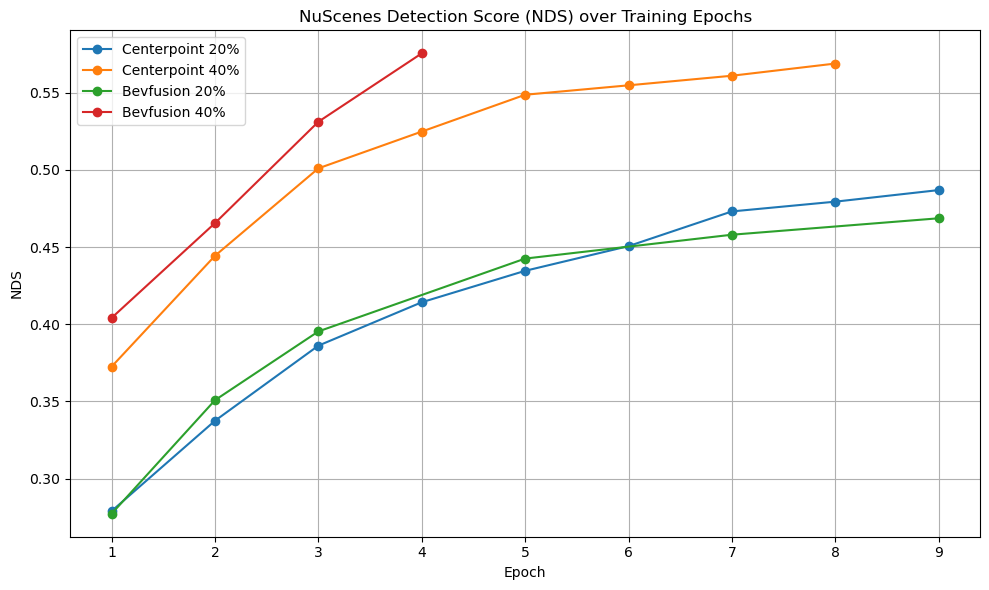

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for label in metrics_df["experiment_label"].unique():

    exp_df = metrics_df[
        metrics_df["experiment_label"] == label
    ]

    plt.plot(
        exp_df["step"],
        exp_df["NDS"],
        marker="o",
        label=label,
    )

plt.xlabel("Epoch")
plt.ylabel("NDS")

plt.title(
    "NuScenes Detection Score (NDS) over Training Epochs"
)

plt.legend()

plt.grid()

plt.tight_layout()

plt.show()

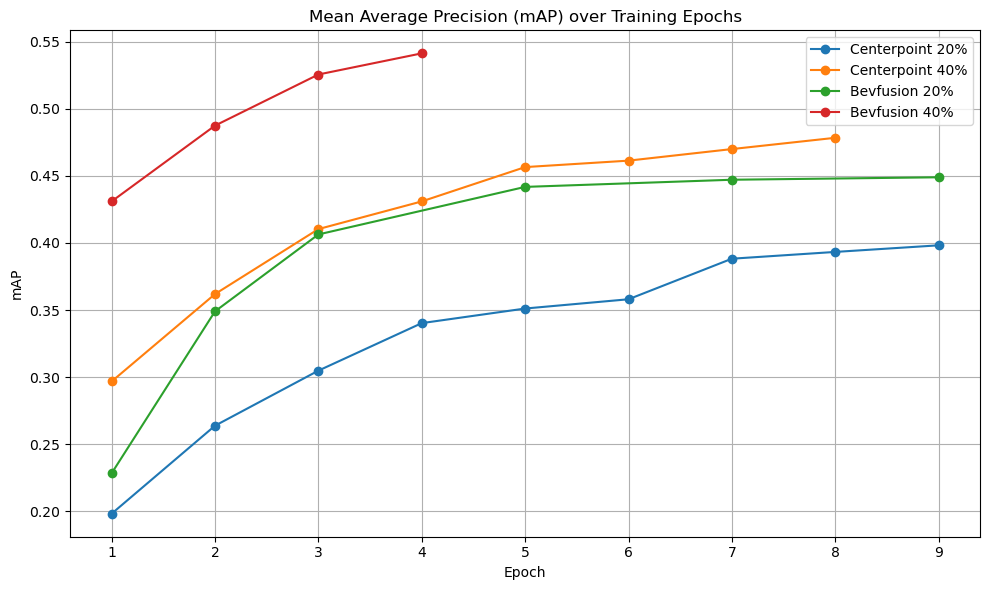

In [16]:
plt.figure(figsize=(10, 6))

for label in metrics_df["experiment_label"].unique():

    exp_df = metrics_df[
        metrics_df["experiment_label"] == label
    ]

    plt.plot(
        exp_df["step"],
        exp_df["mAP"],
        marker="o",
        label=label,
    )

plt.xlabel("Epoch")
plt.ylabel("mAP")

plt.title(
    "Mean Average Precision (mAP) over Training Epochs"
)

plt.legend()

plt.grid()

plt.tight_layout()

plt.show()

# Final detection performance comparison

This section compares the final NDS and mAP scores obtained by each experiment.

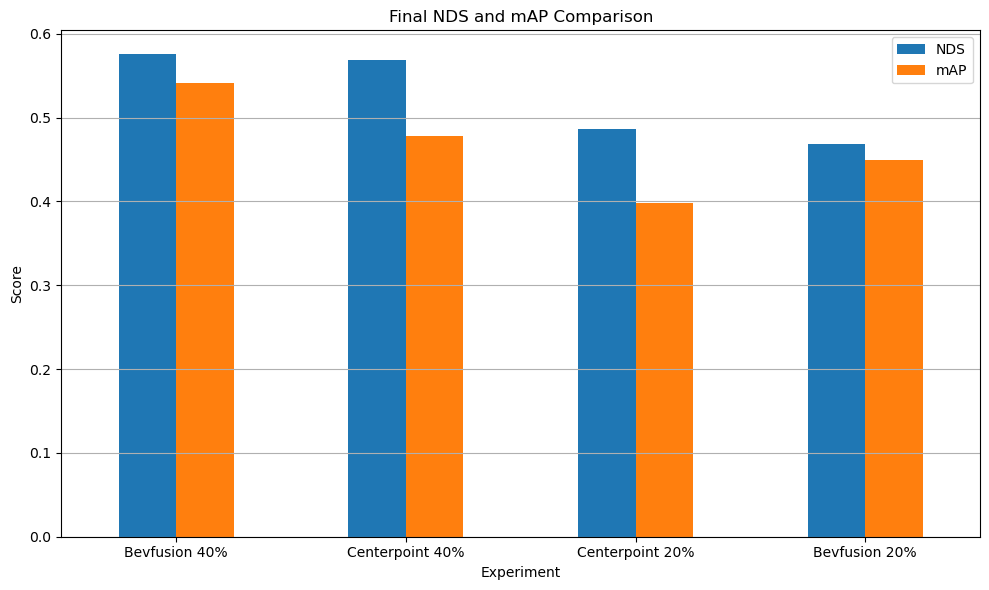

In [17]:
comparison_df = summary_df[
    [
        "experiment_label",
        "NDS",
        "mAP",
    ]
].copy()

comparison_df = comparison_df.sort_values(
    "NDS",
    ascending=False,
)

comparison_df.plot(
    x="experiment_label",
    y=["NDS", "mAP"],
    kind="bar",
    figsize=(10, 6),
)

plt.xlabel("Experiment")
plt.ylabel("Score")

plt.title(
    "Final NDS and mAP Comparison"
)

plt.xticks(rotation=0)

plt.grid(axis="y")

plt.tight_layout()

plt.show()

# Global error comparison

This section compares the final global nuScenes error metrics for all experiments.

Lower values indicate better performance.

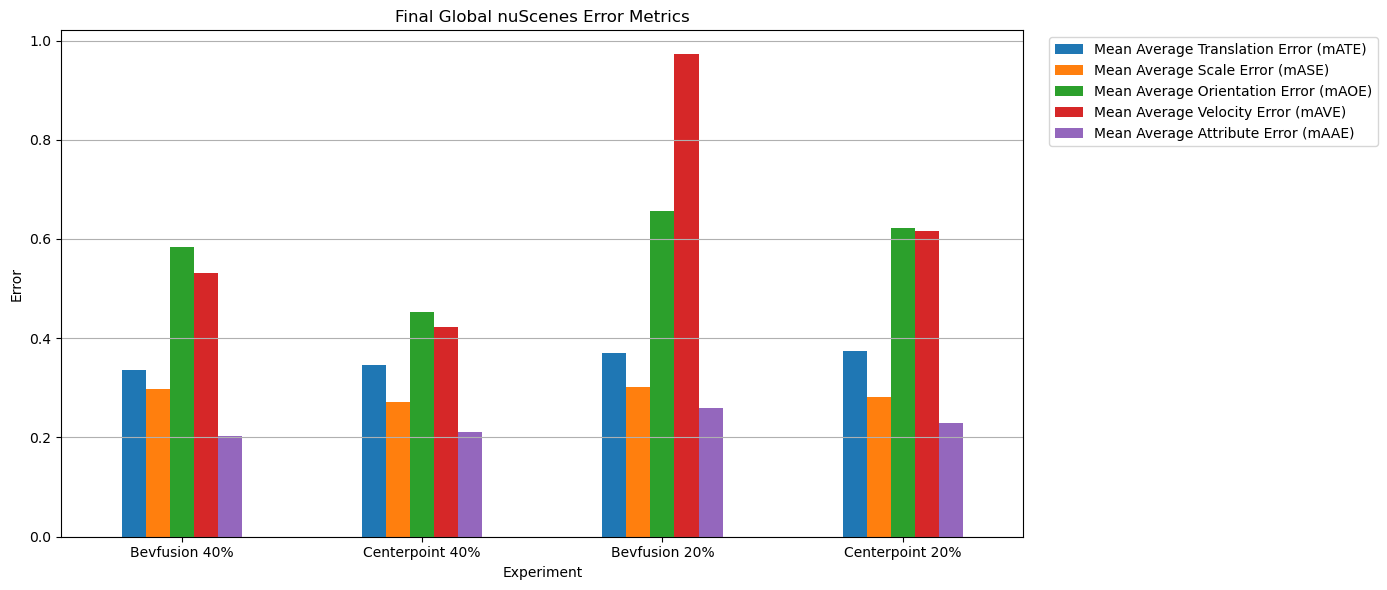

In [19]:
error_cols = [
    "mATE",
    "mASE",
    "mAOE",
    "mAVE",
    "mAAE",
]

error_labels = {
    "mATE": "Mean Average Translation Error (mATE)",
    "mASE": "Mean Average Scale Error (mASE)",
    "mAOE": "Mean Average Orientation Error (mAOE)",
    "mAVE": "Mean Average Velocity Error (mAVE)",
    "mAAE": "Mean Average Attribute Error (mAAE)",
}

errors_df = summary_df[
    ["experiment_label"] + error_cols
].copy()

errors_df = errors_df.sort_values(
    "mATE",
    ascending=True,
)

ax = errors_df.plot(
    x="experiment_label",
    y=error_cols,
    kind="bar",
    figsize=(14, 6),
)

plt.xlabel("Experiment")
plt.ylabel("Error")

plt.title(
    "Final Global nuScenes Error Metrics"
)

plt.xticks(rotation=0)

# Replace legend labels
handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles,
    [error_labels[label] for label in labels],
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.grid(axis="y")

plt.tight_layout()

plt.show()

# Per-class detection performance

This section compares the final Average Precision (AP) obtained for each nuScenes object class.

In [30]:
classes = [
    "car",
    "truck",
    "bus",
    "trailer",
    "construction_vehicle",
    "pedestrian",
    "motorcycle",
    "bicycle",
    "traffic_cone",
    "barrier",
]

per_class_ap = pd.DataFrame(index=classes)

for _, row in final_metrics_df.iterrows():

    label = row["experiment_label"]

    per_class_ap[label] = [

        row[
            [
                f"{cls}_AP_0.5",
                f"{cls}_AP_1.0",
                f"{cls}_AP_2.0",
                f"{cls}_AP_4.0",
            ]
        ].mean()

        for cls in classes
    ]

per_class_ap = per_class_ap.round(3)

per_class_ap

,Bevfusion 40%,Centerpoint 40%,Centerpoint 20%,Bevfusion 20%
car,0.840,0.795,0.744,0.803
truck,0.451,0.452,0.369,0.335
bus,0.534,0.609,0.558,0.381
trailer,0.241,0.238,0.190,0.139
construction_vehicle,0.187,0.109,0.099,0.107
pedestrian,0.842,0.789,0.707,0.823
motorcycle,0.583,0.454,0.374,0.514
bicycle,0.444,0.289,0.169,0.282
traffic_cone,0.723,0.548,0.425,0.654
barrier,0.568,0.501,0.347,0.451


In [31]:
fusion_gain = pd.DataFrame(index=classes)

fusion_gain["20% Fusion Gain"] = (
    per_class_ap["Bevfusion 20%"]
    - per_class_ap["Centerpoint 20%"]
)

fusion_gain["40% Fusion Gain"] = (
    per_class_ap["Bevfusion 40%"]
    - per_class_ap["Centerpoint 40%"]
)

fusion_gain = fusion_gain.round(3)

fusion_gain = fusion_gain.sort_values(
    by="40% Fusion Gain",
    ascending=False,
)

fusion_gain

,20% Fusion Gain,40% Fusion Gain
traffic_cone,0.229,0.175
bicycle,0.113,0.155
motorcycle,0.140,0.129
construction_vehicle,0.008,0.078
barrier,0.104,0.067
pedestrian,0.116,0.053
car,0.059,0.045
trailer,-0.051,0.003
truck,-0.034,-0.001
bus,-0.177,-0.075


# Conclusion

This notebook compared CenterPoint and BEVFusion on reduced nuScenes training subsets (20% and 40%).

Main observations:

- Increasing the training subset size improved both NDS and mAP for all models.
- BEVFusion generally achieved higher mAP values, indicating stronger detection performance across object classes.
- CenterPoint obtained competitive or higher NDS values in some experiments, showing strong overall detection quality despite using LiDAR-only input.
- The largest improvements from increasing the dataset size were observed for complex object classes such as pedestrians, bicycles, and motorcycles.
- Global error metrics decreased as more training data became available, indicating more accurate localization, orientation, and velocity estimation.

Overall, the experiments demonstrate the importance of both sensor fusion and dataset size for 3D object detection performance on nuScenes.